In [356]:
import os
import textwrap
import math
import json
import pandas as pd
import numpy as np
from collections import Counter
from datetime import datetime
from dateutil.relativedelta import relativedelta
from IPython.display import display
from IPython.display import Markdown

from langchain_openai import ChatOpenAI


def to_markdown(text):
  text = text.replace('•', '  *')
  return Markdown(textwrap.indent(text, '> ', predicate=lambda _: True))

llm = ChatOpenAI(
  openai_api_key = os.getenv('OPENAI_API_KEY'),
  model='gpt-4o-mini',
  temperature=1,
)

# 買進賣出需要的手續費
fee = {
  'tax_stock' : 0.003,          # 買進與賣出各0.003
  'tax_future' : 0.00002 * 2,   # 買進與賣出各0.00002
  'fee_stock' : 0.001425 * 2,   # 券商手續費公道價，買進與賣出各0.001425
  'fee_future' : 0.00002 * 2,   # 個家不大相同，以交易稅計算
  'sliding_price' : 0.00001,    # 滑價
}

env = {
    "stock_id" : "TSLA",
    "country" : "us",
    "start_date" : "20230701",
    "end_date" : "20240630",
    "path_out" : "out_stock/GA_factor_20230701_20240630/",
}

# 載入 factors

In [357]:
factors = {}
path_factors = f"{env['path_out']}{env['stock_id']}/factors.json"
print(path_factors)
with open(path_factors, "r") as f:
  factors = json.load(f)

# Access by index using list of keys
key_list = list(factors.keys())
value_list = list(factors.values())
print(key_list)
print(len(key_list))
print(len(value_list))

out_stock/GA_factor_20230701_20240630/TSLA/factors.json
['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20']
20
20


# 延伸factors

In [358]:
from api import factor_expanding

# 讀取舊資料
old_data = {}
path_expand = f"{env['path_out']}{env['stock_id']}/expand.json"
os.makedirs(os.path.dirname(path_expand), exist_ok=True)
if os.path.exists(path_expand):
    with open(path_expand, 'r') as f:
        old_data = json.load(f)

data = factor_expanding(llm, env, key_list, value_list, old_data)

# 儲存資料
with open(path_expand, 'w') as f:
    json.dump(data, f, ensure_ascii=False, indent=4)

running... factor_expanding
Already processed for date 20240628, skip this date
Already processed for date 20240627, skip this date
Already processed for date 20240626, skip this date
Already processed for date 20240625, skip this date
Already processed for date 20240624, skip this date
Already processed for date 20240621, skip this date
Already processed for date 20240620, skip this date
Already processed for date 20240618, skip this date
Already processed for date 20240617, skip this date
Already processed for date 20240614, skip this date
Already processed for date 20240613, skip this date
Already processed for date 20240612, skip this date
Already processed for date 20240611, skip this date
Already processed for date 20240610, skip this date
Already processed for date 20240607, skip this date
Already processed for date 20240606, skip this date
Already processed for date 20240605, skip this date
Already processed for date 20240604, skip this date
Already processed for date 20240603,

# GA 設定

In [352]:
import json
import random
from datetime import datetime
from datetime import timedelta

def split_expand(env, path_expand):
    # 解析日期
    start_day = datetime.strptime(env['start_date'], '%Y%m%d')
    end_day = datetime.strptime(env['end_date'], '%Y%m%d')

    # read train data
    with open(path_expand, 'r') as f:
        content = f.read().strip()
        data_points = json.loads(content)

    # split to training and testing
    total_days = (end_day - start_day).days + 1
    split_point = int(total_days * 3 / 4)
    training_end_day = start_day + timedelta(days=split_point - 1)
    testing_start_day = training_end_day + timedelta(days=1)
    train_datarange = {}
    for date_str, value in data_points["output_data"].items():
        date = datetime.strptime(date_str, '%Y%m%d')
        if start_day <= date <= training_end_day:
            train_datarange[date_str] = value
    test_datarange = {}
    for date_str, value in data_points["output_data"].items():
        date = datetime.strptime(date_str, '%Y%m%d')
        if testing_start_day <= date <= end_day:
            test_datarange[date_str] = value

    return train_datarange, test_datarange

In [353]:
train_datarange, test_datarange = split_expand(env, path_expand)
print(len(train_datarange))
print(train_datarange.keys())
print(len(test_datarange))
print(test_datarange.keys())


187
dict_keys(['20240328', '20240327', '20240326', '20240325', '20240322', '20240321', '20240320', '20240319', '20240318', '20240315', '20240314', '20240313', '20240312', '20240311', '20240308', '20240307', '20240306', '20240305', '20240304', '20240301', '20240229', '20240228', '20240227', '20240226', '20240223', '20240222', '20240221', '20240220', '20240216', '20240215', '20240214', '20240213', '20240212', '20240209', '20240208', '20240207', '20240206', '20240205', '20240202', '20240201', '20240131', '20240130', '20240129', '20240126', '20240125', '20240124', '20240123', '20240122', '20240119', '20240118', '20240117', '20240116', '20240112', '20240111', '20240110', '20240109', '20240108', '20240105', '20240104', '20240103', '20240102', '20231229', '20231228', '20231227', '20231226', '20231222', '20231221', '20231220', '20231219', '20231218', '20231215', '20231214', '20231213', '20231212', '20231211', '20231208', '20231207', '20231206', '20231205', '20231204', '20231201', '20231130', '

# GA Training and Testing

Accuracy

In [343]:
from api import genetic_algorithm
from api import eval

# setting --------------------------------
mode = 0     # 0: 準確率, 1: 期望值
out_folder = f"{env['path_out']}/{env['stock_id']}/ac"
# ----------------------------------------

state_file= out_folder + '/state.json'
file_gen= out_folder + '/generation_results.json'
file_result= out_folder + '/result.json'

print("Start, 第一次跑的話請確認state是空的")
best_individual = genetic_algorithm(factors, population_size=20, generations=50, state_file=state_file, results_file=file_gen, env=env, mode=mode, datarange=train_datarange)
print(f"Best individual: {best_individual}")

individual = best_individual
res_train = eval(individual, train_datarange, env)
res_test = eval(individual, test_datarange, env)
res = {
    "train": res_train,
    "test": res_test,
    "individual": individual,
}
print(res)
print(file_result)
with open(file_result, 'w') as f:
    json.dump(res, f, ensure_ascii=False, indent=4)

Start, 第一次跑的話請確認state是空的
Best individual: [0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0]
{'train': {'tp': 71, 'fp': 59, 'tn': 23, 'fn': 23, 'avail_count': 176, 'ttl_count': 187, 'accuracy': 0.5340909090909091, 'precision': 0.5461538461538461, 'recall': 0.7553191489361702, 'ev': 0.0005719412590276581, 'precision_ev': 0.0009539985673290632, 'rtn_list': [['20230703', 0.002446080391373011], ['20230705', 0.004319449388869163], ['20230706', -0.006189656820571655], ['20230707', -0.004276735503993133], ['20230710', -0.01118222097193888], ['20230711', -0.0017890350980438432], ['20230712', 0.020193804754490733], ['20230713', 0.03277326025427908], ['20230714', -0.023910112745476823], ['20230717', 0.0037157856078117273], ['20230718', 0.016980364446157453], ['20230719', -0.008153547952132151], ['20230720', -0.02122261164985905], ['20230721', -0.032301039573687414], ['20230724', 0.0026603474100735454], ['20230725', 0.016421530451035792], ['20230726', -0.01236392081875671], ['20230727',

In [344]:
print(res['test'])
df = pd.DataFrame([res['train'], res['test']], index=['train', 'test'])
df

{'tp': 23, 'fp': 22, 'tn': 6, 'fn': 11, 'avail_count': 62, 'ttl_count': 63, 'accuracy': 0.46774193548387094, 'precision': 0.5111111111111111, 'recall': 0.6764705882352942, 'ev': -0.001008685372131942, 'precision_ev': -0.0007324502957981212, 'rtn_list': [['20240401', 0.0007087564646340817], ['20240402', -0.011351302460202661], ['20240403', -0.005424709552009448], ['20240404', -0.04978651859389868], ['20240405', 0.013146685699813459], ['20240408', -0.01766629086809478], ['20240409', -0.023878685299970198], ['20240410', -0.03709220027166789], ['20240411', 0.03655913978494621], ['20240412', 0.016867523606729072], ['20240415', 0.03475947832723512], ['20240416', 0.011367251901773078], ['20240417', -0.04873217115689389], ['20240418', 0.003518889019653906], ['20240419', 0.08358388454600123], ['20240422', 0.018104066373041093], ['20240423', -0.020478153747105897], ['20240424', -0.050899344848123834], ['20240425', 0.04772531318151862], ['20240426', -0.04673220549285358], ['20240429', 0.001849420

,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,71,59,23,23,176,187,0.534091,0.546154,0.755319,0.000572,0.000954,"[[20230703, 0.002446080391373011], [20230705, ..."
test,23,22,6,11,62,63,0.467742,0.511111,0.676471,-0.001009,-0.000732,"[[20240401, 0.0007087564646340817], [20240402,..."


Expected Value

In [345]:
from api import genetic_algorithm
from api import eval

# setting --------------------------------
mode = 1     # 0: 準確率, 1: 期望值
out_folder = f"{env['path_out']}/{env['stock_id']}/ev"
# ----------------------------------------

state_file= out_folder + '/state.json'
file_gen= out_folder + '/generation_results.json'
file_result= out_folder + '/result.json'

print("Start, 第一次跑的話請確認state是空的")
best_individual = genetic_algorithm(factors, population_size=20, generations=50, state_file=state_file, results_file=file_gen, env=env, mode=mode, datarange=train_datarange)
print(f"Best individual: {best_individual}")

individual = best_individual
res_train = eval(individual, train_datarange, env)
res_test = eval(individual, test_datarange, env)
res = {
    "train": res_train,
    "test": res_test,
    "individual": individual,
}
print(res)
print(file_result)
with open(file_result, 'w') as f:
    json.dump(res, f, ensure_ascii=False, indent=4)

Start, 第一次跑的話請確認state是空的
Best individual: [0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0]
{'train': {'tp': 78, 'fp': 66, 'tn': 19, 'fn': 21, 'avail_count': 184, 'ttl_count': 187, 'accuracy': 0.5271739130434783, 'precision': 0.5416666666666666, 'recall': 0.7878787878787878, 'ev': 0.0007408042040291853, 'precision_ev': 0.0011515123736048904, 'rtn_list': [['20230703', 0.002446080391373011], ['20230705', 0.004319449388869163], ['20230706', -0.006189656820571655], ['20230707', -0.004276735503993133], ['20230710', -0.01118222097193888], ['20230711', -0.0017890350980438432], ['20230712', 0.020193804754490733], ['20230713', 0.03277326025427908], ['20230714', -0.023910112745476823], ['20230717', 0.0037157856078117273], ['20230718', 0.016980364446157453], ['20230719', -0.008153547952132151], ['20230720', -0.02122261164985905], ['20230721', -0.032301039573687414], ['20230724', 0.0026603474100735454], ['20230725', 0.016421530451035792], ['20230726', -0.01236392081875671], ['20230727',

In [346]:
print(res['test'])
df = pd.DataFrame([res['train'], res['test']], index=['train', 'test'])
df

{'tp': 25, 'fp': 22, 'tn': 6, 'fn': 9, 'avail_count': 62, 'ttl_count': 63, 'accuracy': 0.5, 'precision': 0.5319148936170213, 'recall': 0.7352941176470589, 'ev': -0.00022088483392536384, 'precision_ev': -0.0002179087010412712, 'rtn_list': [['20240401', 0.0007087564646340817], ['20240402', 0.011351302460202661], ['20240403', -0.005424709552009448], ['20240404', -0.04978651859389868], ['20240405', 0.013146685699813459], ['20240408', -0.01766629086809478], ['20240409', -0.023878685299970198], ['20240410', -0.03709220027166789], ['20240411', 0.03655913978494621], ['20240412', 0.016867523606729072], ['20240415', 0.03475947832723512], ['20240416', 0.011367251901773078], ['20240417', -0.04873217115689389], ['20240418', 0.003518889019653906], ['20240419', 0.08358388454600123], ['20240422', 0.018104066373041093], ['20240423', -0.020478153747105897], ['20240424', -0.050899344848123834], ['20240425', 0.04772531318151862], ['20240426', -0.04673220549285358], ['20240429', 0.0018494206290314075], ['2

,tp,fp,tn,fn,avail_count,ttl_count,accuracy,precision,recall,ev,precision_ev,rtn_list
train,78,66,19,21,184,187,0.527174,0.541667,0.787879,0.000741,0.001152,"[[20230703, 0.002446080391373011], [20230705, ..."
test,25,22,6,9,62,63,0.500000,0.531915,0.735294,-0.000221,-0.000218,"[[20240401, 0.0007087564646340817], [20240402,..."


## super training

In [359]:
from api import genetic_algorithm
from api import eval
import os
import shutil

def run(mode, path):
    # setting --------------------------------
    mode = mode     # 0: 準確率, 1: 期望值
    out_folder = path
    # ----------------------------------------

    state_file= out_folder + '/state.json'
    file_gen= out_folder + '/generation_results.json'
    file_result= out_folder + '/result.json'

    print("Start, 第一次跑的話請確認state是空的")
    best_individual = genetic_algorithm(factors, population_size=20, generations=50, state_file=state_file, results_file=file_gen, env=env, mode=mode, datarange=train_datarange)
    print(f"Best individual: {best_individual}")

    individual = best_individual
    res_train = eval(individual, train_datarange, env)
    res_test = eval(individual, test_datarange, env)
    res = {
        "train": res_train,
        "test": res_test,
        "individual": individual,
    }

    old_out_folder = out_folder + '1'
    old_file_result= out_folder + '1/result.json'
    with open(old_file_result, 'r') as f:
        old_res = json.load(f)

    if res['test']['ev'] > old_res['test']['ev']:
        print("New result is better, update the file")
        with open(file_result, 'w') as f:
            json.dump(res, f, ensure_ascii=False, indent=4)
        if os.path.isdir(old_out_folder):
            shutil.rmtree(old_out_folder)
        elif os.path.isfile(old_out_folder):
            os.remove(old_out_folder)
        # rename the file
        os.rename(out_folder, out_folder + '1')
    else:
        print(f"New result is not better, keep the old result, old res: {old_res['test']['ev']}, new: {res['test']['ev']}")
        # remove the directory or file safely
        if os.path.isdir(out_folder):
            shutil.rmtree(out_folder)
        elif os.path.isfile(out_folder):
            os.remove(out_folder)


for i in range(1000):
    run(0, f"{env['path_out']}/{env['stock_id']}/ac")
    run(1, f"{env['path_out']}/{env['stock_id']}/ev")


Start, 第一次跑的話請確認state是空的
Best individual: [1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0]


FileNotFoundError: [Errno 2] No such file or directory: 'out_stock/GA_factor_20230701_20240630//TSLA/ac1/result.json'

# Show Old Data

In [360]:
import os
import json
import pandas as pd
from api import eval

folders = os.listdir(env['path_out'])
results = []
index = []

for folder in folders:
    if folder == "factors_eng.json" or folder == "factors.json" or folder == "old_expand" or folder == ".DS_Store":
        continue
    folders_result = os.listdir(f"{env['path_out']}{folder}")
    # print(f"{folder}:")
    for file in folders_result:
        if file == "factors.json" or file == "factors1.json" or file == "factors2.json" or file == "expand.json" or file == "expand1.json" or file == "expand2.json":
            continue
        path = f"{env['path_out']}{folder}/{file}/result.json"
        with open(path, 'r') as f:
            json_data = json.load(f)
        # print(json_data)
        results.append(json_data['test'])
        index.append(f"{folder}_{file}")
        

print(f"共有 {len(results), len(index)} 筆資料")
print(results)

df = pd.DataFrame(results, index=index)
selected_columns = ['accuracy', 'precision', 'ev', 'precision_ev', 'avail_count', 'tp', 'fp', 'tn', 'fn']  # 替換為您需要的欄位名稱
df['accuracy'] = df['accuracy'].apply(lambda x: f"{x * 100:.2f}%")
df['precision'] = df['precision'].apply(lambda x: f"{x * 100:.2f}%")
df_selected = df.loc[:, selected_columns]
df_sorted = df_selected.sort_index()
df_sorted

共有 (16, 16) 筆資料
[{'tp': 26, 'fp': 24, 'tn': 6, 'fn': 7, 'avail_count': 63, 'ttl_count': 63, 'accuracy': 0.5079365079365079, 'precision': 0.52, 'recall': 0.7878787878787878, 'ev': -0.00016766388304943237, 'precision_ev': -0.0002375808750265983, 'rtn_list': [['20240401', 0.0009956302892859495], ['20240402', 0.00904674149773834], ['20240403', 0.01395219566425787], ['20240404', 0.021739130434782608], ['20240405', -0.014749424278977945], ['20240408', -0.009149277688603574], ['20240409', -0.008384960478530344], ['20240410', 0.017426750198342146], ['20240411', 0.012370140302024216], ['20240412', -0.008470061794161536], ['20240415', -0.020301453914899327], ['20240416', 0.00027282152016141727], ['20240417', -0.016439693993814775], ['20240418', 0.012398743593982476], ['20240419', -0.022994293387042706], ['20240422', 0.0016389736633886745], ['20240423', 0.008198562443845347], ['20240424', -0.01861731688340555], ['20240425', -0.0235148514851484], ['20240426', 0.010264630613909375], ['20240429', -0

,accuracy,precision,ev,precision_ev,avail_count,tp,fp,tn,fn
2330_ac,65.00%,57.69%,0.005523,0.004436,40,15,11,11,3
2330_ev,65.96%,60.61%,0.005146,0.004130,47,20,13,11,3
2454_ac,50.00%,52.00%,0.005023,0.003814,52,13,12,13,14
2454_ev,50.82%,48.78%,0.004333,0.002654,61,20,21,11,9
AAPL_ac,54.55%,51.52%,-0.000383,0.000694,44,17,16,7,4
AAPL_ev,54.55%,51.52%,-0.000383,0.000694,44,17,16,7,4
AMZN_ac,50.79%,52.00%,-0.000168,-0.000238,63,26,24,6,7
AMZN_ev,53.97%,53.57%,0.000987,0.000438,63,30,26,4,3
GOOGL_ac,36.51%,56.00%,-0.002143,0.001034,63,14,11,9,29
GOOGL_ev,35.48%,54.55%,-0.002580,0.000557,62,12,10,10,30


[176.29486162637454, 178.2960379228751, 177.32883370286942, 168.50024842648713, 170.71546823289066, 167.6995591154054, 163.6951141183449, 157.6233021619737, 163.3858744990781, 166.14178959419738, 171.91679152884495, 173.87101300429794, 165.39790103934996, 165.97991789719111, 179.85316419166472, 183.1092378135921, 179.35949868913, 170.23021771356534, 178.35450816690332, 170.01960864067075, 170.33404641223066, 168.69787113834886, 164.66071814003348, 161.9933584032034, 163.83861644695833, 168.87895871375702, 167.8704826380991, 166.12672700306305, 162.85663866099082, 162.0874814607526, 161.94595632717983, 165.1216507575513, 168.97506067984986, 167.99407597397484, 164.62953037541163, 166.43826014913617, 169.61591344550158, 168.71149898543223, 171.6399898379747, 174.95943549540283, 180.76316772216066, 183.60133333655105, 176.95549353413773, 172.4152294936733, 174.5078057029284, 175.59512403325274, 181.63120178617623, 177.1653888311279, 175.5116282507388, 177.58213179909842, 176.3279589047301

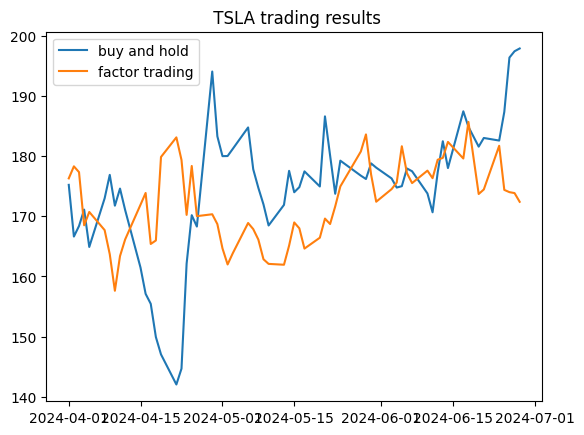

In [361]:
path_price_his = f"{os.path.dirname(os.path.abspath(os.getcwd()))}/history_data/{env['country']}/stock_price/{env['stock_id']}.csv"
df_price_his = pd.read_csv(path_price_his, encoding='utf-8')
df_price_his['Date'] = pd.to_datetime(df_price_his['Date'], format='%Y%m%d')
list_price_rtn = []
list_balance = []
balance = df_price_his[df_price_his['Date'].dt.strftime('%Y%m%d') == res_test['rtn_list'][0][0]]['Open'].values[0]
list_date = []

for date, rtn in res_test['rtn_list']:
    balance = balance * (1 + float(rtn))
    list_date.append(date)
    list_balance.append(balance)
    list_price_rtn.append(df_price_his[df_price_his['Date'].dt.strftime('%Y%m%d') == date]['Close'].values[0])

print(list_balance)
print(list_price_rtn)
print(list_date)
print(len(list_balance))
print(len(list_price_rtn))
print(len(list_date))

df = pd.DataFrame(list_balance, index=list_date, columns=['balance'])
dplot = [datetime.strptime(d, '%Y%m%d').date() for d in list_date]


import matplotlib.pyplot as plt
from datetime import datetime

plt.title(f" {env['stock_id']} trading results")
plt.plot(dplot, list_price_rtn, label = "buy and hold") # blue
plt.plot(dplot, list_balance, label = "factor trading") # orange
plt.legend()


In [315]:
# import os
# import json
# import pandas as pd
# from api import eval

# folders = os.listdir(env['path_out'])
# results = []
# index = []
# print(env['start_date'], env['end_date'])

# for folder in folders:
#     if folder == "factors_eng.json" or folder == "factors.json" or folder == "old_expand":
#         continue
#     folders_result = os.listdir(f"{env['path_out']}{folder}")
#     print(f"{folder}:")
#     for file in folders_result:
#         if file == "factors.json" or file == "expand.json" or file == "expand1.json" or file == "expand2.json":
#             continue
#         path = f"{env['path_out']}{folder}/{file}/generation_results.json"
#         with open(path, 'r') as f:
#             content = f.read().strip()
#         # print(file)
#         best_individual = []
#         for text in content.split('\n'):
#             data = json.loads(text)
#             best_individual = data['best_individual']

#         try:
#             individual = best_individual
#             print(f"{env['path_out']}{folder}/expand.json")
#             train_datarange, test_datarange = split_expand(env, f"{env['path_out']}{folder}/expand.json")
#             res_train = eval(individual, train_datarange)
#             res_test = eval(individual, test_datarange)
#             res = {
#                 "train": res_train,
#                 "test": res_test,
#                 "individual": individual,
#             }

#             file_result = f"{env['path_out']}{folder}/{file}/result.json"
#             print(file_result)
#             with open(file_result, 'w') as f:
#                 json.dump(res, f, ensure_ascii=False, indent=4)
#         except:
#             print("\tError")
#             pass


